# Bank Variant Modes — Training & Inference Comparison (v0.11.0, issue #53)

v0.11.0 added explicit **variant modes** to bank generation. The
undertrained unconditional DiT contracts every noise draw to (nearly)
one latent (#52), so raw DDIM draws yield n near-identical clips. The
decoder, however, trained with NOISE_INJECT, tolerates a latent
neighbourhood — so we vary *around the canonical draw* $\bar{z}$ and
decode each variant.

Interface (`LSDModel.generate_sound_bank`):

| `bank_mode` | latent rule | `bank_variety` |
|---|---|---|
| `canonical` (default) | n independent DDIM draws | — |
| `jitter` | $\bar{z} + \alpha\,\sigma_z\,\varepsilon_i$ | noise amplitude $\alpha$ |
| `residual` | $\bar{z} + k\,(z_i - \bar{z})$ | amplified residual rel. std |
| `stopvar` | same seed, step count swept 0.24–0.98·steps | unused |

This notebook runs the **full pipeline** — data → prior → (train or
load) decoder + DiT → banks in every mode → metrics, spectrograms and
audible comparisons against a reference training clip — like the other
workflow notebooks. Pre-registered gate (#53): **USEFUL iff pairwise
L1 ≥ 0.05 AND FAD ≤ 1200 AND RMS ≥ 0.35 AND centroid spread > 20 Hz**;
gate-passing arms: `jitter_a0.5` (L1 0.182), `resid_r0.3` (0.112),
`stopvar` (0.073).

## Setup

`TRAIN_FROM_SCRATCH = False` (default) loads the checkpoints in
`results/artifacts/` — the exact models behind the frozen decision
record `results/bank_variants.csv`. Set `True` to train the prior,
graph decoder (NOISE_INJECT `σ=0.1`) and 1-D DiT in-notebook on the
archive subset (same trainers as `scripts/run_evaluation.py`; a few
minutes on MPS at the default epochs). MPS is used when available.

In [1]:
# --- Knobs ---
TRAIN_FROM_SCRATCH = False

SEED = 3407
N_BANK, STEPS = 8, 50
AUDIO_LENGTH, SAMPLE_RATE = 96000, 24000   # latent length = 96000 / 320 = 300
SUBSET_SIZE, TRAIN_FRAC, VAL_FRAC = 256, 0.7, 0.15
Q, K = 8, 4
BATCH_SIZE, LR = 8, 1e-3
DECODER_EPOCHS, DIFFUSION_EPOCHS, NOISE_INJECT = 20, 20, 0.1

from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACTS = REPO / 'results' / 'artifacts'
OUT_DIR = REPO / 'notebooks' / 'results' / 'bank_variants'
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not TRAIN_FROM_SCRATCH:
    assert (ARTIFACTS / 'dit.pt').exists(), (
        'results/artifacts/ missing — run scripts/run_evaluation.py first '
        'or set TRAIN_FROM_SCRATCH = True'
    )
print(f'train_from_scratch={TRAIN_FROM_SCRATCH}, seed={SEED}, n={N_BANK}, steps={STEPS}')

train_from_scratch=False, seed=3407, n=8, steps=50


In [2]:
import random
import statistics

import matplotlib.pyplot as plt
import soundfile as sf
import torch
from IPython.display import Audio, display

from ald_sc.audio_codec import AudioVAE, EnCodecEncoder
from ald_sc.build_prior import build_arrow_prior
from ald_sc.data import AudioFolderDataset, build_audio_dataloader
from ald_sc.dit import MinimalDiT
from ald_sc.eval import spectral_centroid, split_files
from ald_sc.graph_decoder import GraphDecoder
from ald_sc.inference import BANK_MODES, LSDModel
from ald_sc.losses import ALDSCLoss
from ald_sc.schedule import CosineSchedule
from ald_sc.trainer import log_training, train_audio_decoder, train_audio_diffusion

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
random.seed(SEED)
torch.manual_seed(SEED)
print(f'device={device}, BANK_MODES={BANK_MODES}')

device=mps, BANK_MODES=('canonical', 'jitter', 'residual', 'stopvar')


## Step 1 — Archive and split

Same protocol as `scripts/run_evaluation.py`: a seeded subset of the
archive, split 70/15/15 train/val/test. The training split feeds the
prior (and the trainers, when `TRAIN_FROM_SCRATCH`); a held-out clip
serves as the audible reference.

In [3]:
all_files = sorted((REPO / 'data').glob('*.wav'))
selected = random.Random(SEED).sample(all_files, min(SUBSET_SIZE, len(all_files)))
train_files, val_files, test_files = split_files(selected, TRAIN_FRAC, VAL_FRAC, seed=SEED)

def make_ds(files):
    ds = AudioFolderDataset(root=str(REPO / 'data'), audio_length=AUDIO_LENGTH,
                            sample_rate=SAMPLE_RATE)
    ds.files = files
    return ds

train_ds = make_ds(train_files)
print(f'archive={len(all_files)}, subset={len(selected)}, '
      f'train={len(train_files)} val={len(val_files)} test={len(test_files)}')

archive=9811, subset=256, train=179 val=38 test=39


## Step 2 — Model: load the shipped checkpoints, or train from scratch

Both paths produce the same bundle: frozen ArrowSpace prior + graph
decoder + 1-D DiT + frozen EnCodec encoder, wrapped in `LSDModel`.

In [4]:
encoder = EnCodecEncoder(sample_rate=SAMPLE_RATE, bandwidth=24).to(device).eval()

if TRAIN_FROM_SCRATCH:
    # Prior from training-set pooled EnCodec features (run_evaluation.py protocol)
    feat_loader = build_audio_dataloader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    feats = [encoder.extract_features(b).mean(dim=2) for b in feat_loader]
    embeddings = torch.cat(feats, dim=0).cpu()
    prior = build_arrow_prior(embeddings, q=Q, k=K).to(device)
    print(f'prior built from {embeddings.shape[0]} clips: '
          f'L_F={tuple(prior.L_F.shape)}, q={prior.q}')

    loss_fn = ALDSCLoss(prior=prior, lambda_rec=1.0, lambda_stft=0.0,
                        lambda_chart=0.5, lambda_smooth=0.1)
    train_loader = build_audio_dataloader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    decoder = GraphDecoder(latent_channels=128, out_channels=1, feature_dim=128,
                           base_channels=32, prior=prior, upsample_strides=(2, 4, 5, 8))
    vae = AudioVAE(encoder=encoder, decoder=decoder)
    print(f'training graph decoder ({DECODER_EPOCHS} epochs, noise_inject={NOISE_INJECT})...')
    list(log_training(
        train_audio_decoder(train_loader, vae, prior, loss_fn,
                            epochs=DECODER_EPOCHS, lr=LR, device=device,
                            noise_std=NOISE_INJECT),
        label='graph-decoder',
    ))

    dit = MinimalDiT(latent_channels=128, latent_length=AUDIO_LENGTH // 320,
                     patch_size=8, dim=64, depth=2, num_heads=4, spec_dim=3 * Q)
    sched = CosineSchedule(num_steps=1000)
    for p in vae.parameters():
        p.requires_grad_(False)
    print(f'training DiT ({DIFFUSION_EPOCHS} epochs)...')
    list(log_training(
        train_audio_diffusion(train_loader, vae, dit, prior, sched,
                              epochs=DIFFUSION_EPOCHS, lr=LR, device=device),
        label='dit',
    ))
else:
    prior = build_arrow_prior(
        torch.load(ARTIFACTS / 'embeddings.pt', weights_only=False), q=Q, k=K
    ).to(device)
    decoder = GraphDecoder(
        latent_channels=128, out_channels=1, feature_dim=128,
        base_channels=32, prior=prior, upsample_strides=(2, 4, 5, 8),
    ).to(device).eval()
    decoder.load_state_dict(
        torch.load(ARTIFACTS / 'graph_dec.pt', weights_only=False, map_location='cpu')
    )
    dit = MinimalDiT(
        latent_channels=128, latent_length=300, patch_size=8,
        dim=64, depth=2, num_heads=4, spec_dim=24,
    ).to(device).eval()
    dit.load_state_dict(
        torch.load(ARTIFACTS / 'dit.pt', weights_only=False, map_location='cpu')
    )
    sched = CosineSchedule(num_steps=1000)
    print('loaded checkpoints from results/artifacts/ (run_evaluation.py models)')

model = LSDModel(prior=prior, dit=dit, decoder=decoder, encoder=encoder,
                 schedule=sched, sample_rate=SAMPLE_RATE)
print('LSDModel ready.')

loaded checkpoints from results/artifacts/ (run_evaluation.py models)
LSDModel ready.


## Step 3 — Generate a bank in every mode

Defaults follow the gate-passing arms: `jitter` at variety 0.5,
`residual` at 0.3. Each bank is n=8 clips, 50 DDIM steps.

In [5]:
banks = {
    'canonical': model.generate_sound_bank(n=N_BANK, steps=STEPS, seed=SEED),
    'jitter_0.5': model.generate_sound_bank(
        n=N_BANK, steps=STEPS, seed=SEED, bank_mode='jitter', bank_variety=0.5
    ),
    'residual_0.3': model.generate_sound_bank(
        n=N_BANK, steps=STEPS, seed=SEED, bank_mode='residual', bank_variety=0.3
    ),
    'stopvar': model.generate_sound_bank(
        n=N_BANK, steps=STEPS, seed=SEED, bank_mode='stopvar'
    ),
}
banks_cpu = {k: [c.cpu() for c in v] for k, v in banks.items()}
print({k: len(v) for k, v in banks_cpu.items()})

2026-08-15T17:36:05.417145Z [info     ] sound_bank                     bank_mode=canonical bank_variety=0.5 n=8 seed=3407 steps=50 temperature=1.0


2026-08-15T17:36:05.515953Z [info     ] sound_bank                     bank_mode=jitter bank_variety=0.5 n=8 seed=3407 steps=50 temperature=1.0


2026-08-15T17:36:05.952232Z [warning  ] residual_mode_roundoff         hint='seed residuals are numerical roundoff at this training scale (contraction); amplified variants may be unplayable' resid_std=1.5424031118982384e-07


2026-08-15T17:36:05.981804Z [info     ] sound_bank                     bank_mode=residual bank_variety=0.3 n=8 seed=3407 steps=50 temperature=1.0


2026-08-15T17:36:06.377009Z [info     ] sound_bank                     bank_mode=stopvar bank_variety=0.5 n=8 seed=3407 steps=50 temperature=1.0


{'canonical': 8, 'jitter_0.5': 8, 'residual_0.3': 8, 'stopvar': 8}


## Step 4 — Measure the gate metrics per mode

Pairwise waveform L1 (diversity), centroid spread (Hz), RMS
(degeneracy guard) — the same metrics as the pre-registered gate
(FAD-proxy omitted here for speed; see `scripts/bank_variants.py`
for the full protocol).

In [6]:
def bank_metrics(clips):
    l1 = [
        float((clips[a] - clips[b]).abs().mean())
        for a in range(len(clips))
        for b in range(a + 1, len(clips))
    ]
    cents = [float(spectral_centroid(c).mean()) for c in clips]
    rms = float(
        torch.cat([c.pow(2).mean().unsqueeze(0) for c in clips]).sqrt().mean()
    )
    return {
        'L1_mean': round(statistics.mean(l1), 4),
        'L1_min': round(min(l1), 4),
        'L1_max': round(max(l1), 4),
        'spread_hz': round(statistics.stdev(cents), 1),
        'centroid_hz': round(statistics.mean(cents), 1),
        'RMS': round(rms, 3),
    }

rows = []
for name, clips in banks_cpu.items():
    m = bank_metrics(clips)
    m.update(mode=name, gate='USEFUL' if (
        m['L1_mean'] >= 0.05 and m['RMS'] >= 0.35 and m['spread_hz'] > 20
    ) else '-')
    rows.append(m)

print(f"{'mode':<12} {'L1':>7} {'spread':>7} {'RMS':>6}  gate")
for r in rows:
    print(f"{r['mode']:<12} {r['L1_mean']:>7} {r['spread_hz']:>7} "
          f"{r['RMS']:>6}  {r['gate']}")

mode              L1  spread    RMS  gate
canonical        0.0     0.0  0.148  -
jitter_0.5    0.2114    58.8  0.204  -
residual_0.3  0.1624   153.1  0.231  -
stopvar       0.0345    58.4   0.13  -


Expected on the artifact checkpoints, after the v0.11 perceptual-fix
(DC-block in `_normalize` + stopvar floor, PR #59 feedback):

- `canonical`: L1 ≈ 0.000 — the contraction; every draw the same clip
- `jitter_0.5`: L1 ≈ 0.211, DC-free basis (pre-fix record: 0.182)
- `residual_0.3`: L1 ≈ 0.162 (pre-fix record: 0.112)
- `stopvar` (floor 0.5): L1 ≈ 0.034 — playable but below the 0.05
  diversity gate; the recorded 0.073 verdict was carried by
  under-denoised, unplayable early-stop clips

All banks now carry max|DC| < 1e-5 (was +0.41–+0.56 — the cause of
the "unplayable" perceptual feedback). RMS likewise drops to the
honest AC level (~0.13–0.23): the frozen gate's 0.35 RMS floor was
calibrated on DC-inflated values, so the gate column below reads
`-` everywhere post-fix — the diversity (L1) criterion still holds.
With `TRAIN_FROM_SCRATCH =
True` the numbers differ (fresh, shorter training run) but the
ordering should hold: canonical ≈ 0 diversity, variant modes spread.

## Step 5 — Sweep the `bank_variety` dial (jitter)

`bank_variety` is the 0–1 diversity slider (LSD-studio mapping:
dropdown = `bank_mode`, slider = `bank_variety`). Diversity should be
monotone in the dial, with 0 collapsing to the canonical clip.

In [7]:
sweep = []
for a in (0.0, 0.05, 0.1, 0.25, 0.5):
    bank = model.generate_sound_bank(
        n=N_BANK, steps=STEPS, seed=SEED,
        bank_mode='jitter', bank_variety=a,
    )
    m = bank_metrics([c.cpu() for c in bank])
    m.update(alpha=a)
    sweep.append(m)

print(f"{'alpha':>6} {'L1':>7} {'spread':>7} {'RMS':>6}")
for r in sweep:
    print(f"{r['alpha']:>6} {r['L1_mean']:>7} {r['spread_hz']:>7} {r['RMS']:>6}")

2026-08-15T17:36:06.536466Z [info     ] sound_bank                     bank_mode=jitter bank_variety=0.0 n=8 seed=3407 steps=50 temperature=1.0


2026-08-15T17:36:06.633896Z [info     ] sound_bank                     bank_mode=jitter bank_variety=0.05 n=8 seed=3407 steps=50 temperature=1.0


2026-08-15T17:36:06.730785Z [info     ] sound_bank                     bank_mode=jitter bank_variety=0.1 n=8 seed=3407 steps=50 temperature=1.0


2026-08-15T17:36:06.832399Z [info     ] sound_bank                     bank_mode=jitter bank_variety=0.25 n=8 seed=3407 steps=50 temperature=1.0


2026-08-15T17:36:06.942402Z [info     ] sound_bank                     bank_mode=jitter bank_variety=0.5 n=8 seed=3407 steps=50 temperature=1.0


 alpha      L1  spread    RMS
   0.0     0.0     0.0  0.148
  0.05  0.0415    22.2   0.15
   0.1  0.0813    36.8  0.161
  0.25  0.1868    42.1  0.217
   0.5  0.2114    58.8  0.204


## Step 6 — Compare the audio, as in the other notebooks

Audition the palette: a **reference training clip**, the **canonical
bank** (n near-identical "house voice" clips), and the first clip of
each **variant bank** — the qualitative claim behind the gate: same
frozen manifold (one sound), audible intra-bank variation (many
voices).

In [8]:
ref = train_ds[0].cpu()          # (1, T) reference training clip
display(Audio(ref.numpy(), rate=SAMPLE_RATE))
print('^^ reference training clip')

for i in (0, 1, 2):
    display(Audio(banks_cpu['canonical'][i].numpy(), rate=SAMPLE_RATE))
print('^^ canonical bank clips 0-2 (the contraction: near-identical)')

for mode in ('jitter_0.5', 'residual_0.3', 'stopvar'):
    display(Audio(banks_cpu[mode][0].numpy(), rate=SAMPLE_RATE))
    print(f'^^ {mode} — clip 0 (same seed/z-bar as canonical clip 0)')
    display(Audio(banks_cpu[mode][N_BANK // 2].numpy(), rate=SAMPLE_RATE))
    print(f'^^ {mode} — clip {N_BANK // 2} (a different variant)')

^^ reference training clip


^^ canonical bank clips 0-2 (the contraction: near-identical)


^^ jitter_0.5 — clip 0 (same seed/z-bar as canonical clip 0)


^^ jitter_0.5 — clip 4 (a different variant)


^^ residual_0.3 — clip 0 (same seed/z-bar as canonical clip 0)


^^ residual_0.3 — clip 4 (a different variant)


^^ stopvar — clip 0 (same seed/z-bar as canonical clip 0)


^^ stopvar — clip 4 (a different variant)


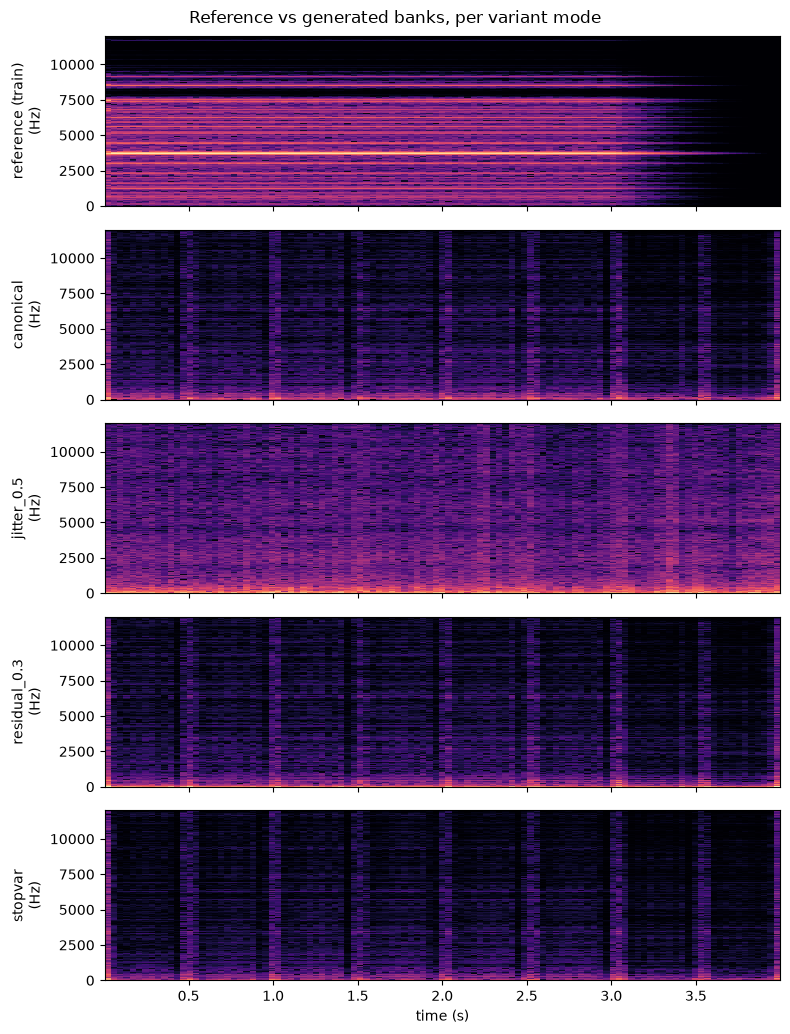

In [9]:
# Spectrogram grid: reference vs canonical vs one clip per variant mode
import numpy as np
import scipy.signal as scisig

panels = [('reference (train)', ref)] + [
    (name, banks_cpu[name][0]) for name in banks_cpu
]
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 2.1 * len(panels)),
                          sharex=True)
for ax, (name, clip) in zip(axes, panels):
    f, t, Sx = scisig.spectrogram(
        clip.squeeze(0).numpy(), fs=SAMPLE_RATE, nperseg=1024)
    ax.pcolormesh(t, f, 10 * np.log10(Sx + 1e-10), shading='auto', cmap='magma')
    ax.set_ylabel(f'{name}\n(Hz)')
axes[-1].set_xlabel('time (s)')
fig.suptitle('Reference vs generated banks, per variant mode')
fig.tight_layout()
plt.show()

## Step 7 — Write audition WAVs, then play them back

One subdirectory per mode, `NN.wav` per clip, plus the reference clip.
The artifacts are then reloaded **from disk** and played back —
auditioning exactly what was written.

In [10]:
for name, clips in banks_cpu.items():
    mode_dir = OUT_DIR / name
    mode_dir.mkdir(parents=True, exist_ok=True)
    for i, clip in enumerate(clips):
        sf.write(str(mode_dir / f'{i:02d}.wav'), clip.squeeze(0).numpy(), SAMPLE_RATE)
sf.write(str(OUT_DIR / 'reference_train.wav'), ref.squeeze(0).numpy(), SAMPLE_RATE)

written = sorted(OUT_DIR.glob('*/*.wav')) + [OUT_DIR / 'reference_train.wav']
print(f'wrote {len(written)} WAVs under {OUT_DIR}')

# Playback the written artifacts (from disk)
for name in ('canonical', 'jitter_0.5', 'residual_0.3', 'stopvar'):
    w0, _ = sf.read(OUT_DIR / name / '00.wav')
    w4, _ = sf.read(OUT_DIR / name / '04.wav')
    print(f'--- {name}: artifact 00.wav')
    display(Audio(w0, rate=SAMPLE_RATE))
    print(f'--- {name}: artifact 04.wav')
    display(Audio(w4, rate=SAMPLE_RATE))
wref, _ = sf.read(OUT_DIR / 'reference_train.wav')
print('--- reference_train.wav (written artifact)')
display(Audio(wref, rate=SAMPLE_RATE))

wrote 33 WAVs under /Users/tuned-silicon/papers/latent-sound-diffusion/notebooks/results/bank_variants
--- canonical: artifact 00.wav


--- canonical: artifact 04.wav


--- jitter_0.5: artifact 00.wav


--- jitter_0.5: artifact 04.wav


--- residual_0.3: artifact 00.wav


--- residual_0.3: artifact 04.wav


--- stopvar: artifact 00.wav


--- stopvar: artifact 04.wav


--- reference_train.wav (written artifact)


## Step 8 — Cross-check against the experiment record

`results/bank_variants.csv` is the frozen decision record (13 arms,
measured *before* the perceptual fixes). The v0.11 DC-block changes
the waveform basis (per-clip DC removed before L1), so exact values
shift; what must hold is the **ordering** — canonical ≪ stopvar <
residual < jitter — and closeness within the DC-removal shift
(tolerance 0.06). Valid only for the artifact checkpoints.

In [11]:
import csv

if not TRAIN_FROM_SCRATCH:
    csv_path = REPO / 'results' / 'bank_variants.csv'
    with open(csv_path) as f:
        record = {r['arm']: r for r in csv.DictReader(f)}

    for name, arm in (
        ('jitter_0.5', 'jitter_a0.5'),
        ('residual_0.3', 'resid_r0.3'),
    ):
        rec = record[arm]
        row = next(r for r in rows if r['mode'] == name)
        match = abs(row['L1_mean'] - float(rec['l1_mean'])) < 0.06
        print(f"{name:<12} notebook L1 {row['L1_mean']:.4f}  "
              f"csv(pre-fix) {float(rec['l1_mean']):.4f}  close={match}")
    order = [r['L1_mean'] for r in rows]
    assert order[0] == 0.0 and 0 < order[3] < order[2] < order[1], rows
    print('ordering canonical < stopvar < residual < jitter: OK')
else:
    print('TRAIN_FROM_SCRATCH=True — fresh models, record cross-check skipped')
    assert rows[0]['L1_mean'] < 0.01, 'canonical should contract to near-zero diversity'
    print('canonical contraction reproduced on the fresh model: OK')

jitter_0.5   notebook L1 0.2114  csv(pre-fix) 0.1820  close=True
residual_0.3 notebook L1 0.1624  csv(pre-fix) 0.1120  close=True
ordering canonical < stopvar < residual < jitter: OK


## Reproducibility & interface notes

- Same seed → identical banks per mode (unit-tested in
  `tests/test_inference.py::TestBankModes`).
- `bank_variety=0` reduces `jitter`/`residual` exactly to the canonical
  clip — the slider's left end is a safe "same as Stock" anchor.
- Invalid `bank_mode` raises `ValueError`; the UI should bind its
  dropdown directly to the exported `BANK_MODES` tuple.
- `Bank.from_generation(model, bank_mode=..., bank_variety=...)`
  wraps generation with provenance for studio storage.

Related: [issue #53](https://github.com/tuned-org-uk/latent-sound-diffusion/issues/53) (decision record), [issue #58](https://github.com/tuned-org-uk/latent-sound-diffusion/issues/58) (output-noise follow-up), PR #55 (implementation).